In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction, user_similarities

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from lib.matrix_dataset import MatrixDataset
from recommenders.vae import MultiVAE
from recommenders.metrics import NDCG_binary_at_k_batch, Recall_at_k_batch_torch, mpr
import datetime

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    device = mps_device
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print ("MPS device not found.")

if device == torch.device("cuda"):
    dtype = torch.float32
    print("Using CUDA.")
elif device == torch.device("cpu"):
    dtype = torch.float64
    print("Using CPU.")
elif device == torch.device("mps"):
    dtype = torch.float32
    print("Using MPS.")

# device = "cpu"
# dtype = torch.float32

tensor([1.], device='mps:0')
Using MPS.


# Import data

In [3]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    load_spotify_tracks=False,
    penality_factors={"short_term": 1, "medium_term": 1, "long_term": 1},
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,NaN,dany,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12425,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12426,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12427,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqPq,...,NaN,N

In [4]:
# df = pd.read_csv(os.path.join(data_path.DATA_PATH, "artificial_data.csv"), index_col=0)
# df["type"] = "top_track"
# spoti.NUMERICAL_FEATURES = ["danceability", "instrumentalness", "duration_ms"]
# spoti.PRETTY_PRINT_FEATURES = ["username", "id", "danceability", "instrumentalness", "duration_ms"]
# df

## Setup the dataset

In [5]:
df_matrix_mf = df.copy()
df_matrix_mf.drop_duplicates(subset=["username", "id"], inplace=True) # A user can have multiple entries for the same track (if it's in multiple playlists)
df_matrix_mf.loc[df_matrix_mf["type"] == "liked_track", "affinity"] = 0.5
df_matrix_mf.loc[df_matrix_mf["type"] == "playlist", "affinity"] = 0.3

used_types = ["top_track", "liked_track", "playlist"]
# used_types = ["top_track"]
df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]
df_matrix_mf["id"] = df_matrix_mf["id"].astype("category")
df_matrix_mf["username"] = df_matrix_mf["username"].astype("category")
df_matrix_mf

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_62296/1256999401.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12422,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, CH, CW, CY, C...",1,330733,False,{'isrc': 'GBN9X1400200'},{'spotify': 'https://open.spotify.com/track/16...,https://api.spotify.com/v1/tracks/16KX9LfZCjRP...,16KX9LfZCjRPdX84PX1XF9,...,NaN,0.30,dany,2014,"[rock, rock, rock, rock, rock, rock, rock]",2022-01-28 08:37:40+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12423,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, CH, CW, CY, C...",1,1026853,False,{'isrc': 'GBN9Y1800013'},{'spotify': 'https://open.spotify.com/track/71...,https://api.spotify.com/v1/tracks/715b4AT3ynJy...,715b4AT3ynJyYmtFucyzDu,...,NaN,0.30,dany,1977,"[rock, rock, rock, rock, rock, rock, rock]",2022-09-25 09:41:36+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12424,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,0.30,dany,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12426,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7

In [6]:
df_matrix_mf_filtered = preprocessing.filter_rows_by_min_number_of_occurence(df_matrix_mf, "id", 2)
df_matrix_mf_filtered

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
7,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,188106,False,{'isrc': 'USSM12107750'},{'spotify': 'https://open.spotify.com/track/6Y...,https://api.spotify.com/v1/tracks/6Y46tOTRhkBa...,6Y46tOTRhkBamosyuWa6YX,...,medium_term,0.86,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
14,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196519,False,{'isrc': 'QMJMT2204481'},{'spotify': 'https://open.spotify.com/track/35...,https://api.spotify.com/v1/tracks/35ovElsgyAtQ...,35ovElsgyAtQwYPYnZJECg,...,medium_term,0.72,jaslkh,2022,"[pop, pop, rap]",NaT,NaN,NaN,NaN,NaN
15,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,282052,False,{'isrc': 'FRUM71700532'},{'spotify': 'https://open.spotify.com/track/5x...,https://api.spotify.com/v1/tracks/5xYNLzZzgN3r...,5xYNLzZzgN3r6YPcQgNcJD,...,medium_term,0.70,jaslkh,2017,"[rap, rap]",NaT,NaN,NaN,NaN,NaN
16,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,155893,False,{'isrc': 'FR9W12145737'},{'spotify': 'https://open.spotify.com/track/3n...,https://api.spotify.com/v1/tracks/3nR6ytbSKOF4...,3nR6ytbSKOF4NxsgqrYG9u,...,medium_term,0.68,jaslkh,2022,"[rap, rap]",NaT,NaN,NaN,NaN,NaN
23,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,187320,False,{'isrc': 'GBENL1601640'},{'spotify': 'https://open.spotify.com/track/3N...,https://api.spotify.com/v1/tracks/3NfqN997u9A3...,3NfqN997u9A3YAAafgzhIa,...,medium_term,0.54,jaslkh,2016,"[rock, rock, emo, rock]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12386,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,365626,False,{'isrc': 'GBAYE7800619'},{'spotify': 'https://open.spotify.com/track/5g...,https://api.spotify.com/v1/tracks/5gOd6zDC8vhl...,5gOd6zDC8vhlYjqbQdJVWP,...,NaN,0.50,dany,1978,"[rock, rock, rock, rock, rock]",2019-12-09 06:53:08+00:00,NaN,NaN,NaN,NaN
12390,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,1413306,False,{'isrc': 'GBN9Y1100065'},{'spotify': 'https://open.spotify.com/track/1M...,https://api.spotify.com/v1/tracks/1Mzm1CNqVxtw...,1Mzm1CNqVxtwbCYhOo843s,...,NaN,0.30,dany,1971,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:49:49+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12393,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,284413,False,{'isrc': 'GBN9Y1100080'},{'spotify': 'https://open.spotify.com/track/25...,https://api.spotify.com/v1/tracks/25tZHMv3ctlz...,25tZHMv3ctlzqDaHAeuU9c,...,NaN,0.30,dany,1973,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:50:19+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12399,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,304200,False,{'isrc': 'GBN9Y1100088'},{'spotify': 'https://open.spotify.com/track/7a...,https://api.spotify.com/v1/tracks/7aE5WXu5sFeN...,7aE5WXu5sFeNRh3Z05wwu4,...,NaN,0.30,dany,1975,"[rock, rock, rock, rock,

In [7]:
df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_62296/3495685520.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_62296/3495685520.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()


In [8]:
sparsity, users_count, items_count, interactions_count = preprocessing.compute_sparsity(df_matrix_mf_filtered, "username", "id")
print(f"After filtering, there is {len(users_count)} users, {len(items_count)} items and {len(interactions_count)} interactions, so the sparsity is {sparsity*100:.2f}%.")

After filtering, there is 8 users, 428 items and 917 interactions, so the sparsity is 26.78%.


In [9]:
display(users_count)
shuffled_users_df = preprocessing.permute_users(users_count=users_count, seed=42)
display(shuffled_users_df)

username
owen         274
michelle     116
jaslkh       112
paul         112
lsirwguhu    108
arthur        81
brenda        69
dany          45
Name: count, dtype: int64

,count,old_index
username,,
michelle,116,michelle
arthur,81,arthur
owen,274,owen
dany,45,dany
jaslkh,112,jaslkh
lsirwguhu,108,lsirwguhu
paul,112,paul
brenda,69,brenda


In [10]:
train_df, val_df, test_df = preprocessing.split_users_train_validation_test(df_users_shuffled=shuffled_users_df, validation_percentage=0.2, test_percentage=0.2)
print("Original data:")
display(shuffled_users_df)
print("Train data:")
display(train_df)
print("Validation data:")
display(val_df)
print("Test data:")
display(test_df)

Original data:


,count,old_index
username,,
michelle,116,michelle
arthur,81,arthur
owen,274,owen
dany,45,dany
jaslkh,112,jaslkh
lsirwguhu,108,lsirwguhu
paul,112,paul
brenda,69,brenda


Train data:


,count,old_index
username,,
michelle,116,michelle
arthur,81,arthur
owen,274,owen
dany,45,dany


Validation data:


,count,old_index
username,,
jaslkh,112,jaslkh
lsirwguhu,108,lsirwguhu


Test data:


,count,old_index
username,,
paul,112,paul
brenda,69,brenda


Train data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
1505,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,239597,False,{'isrc': 'TCACP1635569'},{'spotify': 'https://open.spotify.com/track/4y...,https://api.spotify.com/v1/tracks/4yXKLDrHYrff...,4yXKLDrHYrffSVmQOFdbDA,...,medium_term,1.00,owen,2016,"[emo, emo, emo, indie, emo]",NaT,NaN,NaN,NaN,NaN
1507,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,276000,True,{'isrc': 'TCACP1635556'},{'spotify': 'https://open.spotify.com/track/19...,https://api.spotify.com/v1/tracks/19aUuDd6udp1...,19aUuDd6udp1ACNo9t3IuZ,...,medium_term,0.96,owen,2016,"[emo, emo, emo, indie, emo]",NaT,NaN,NaN,NaN,NaN
1514,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,250546,False,{'isrc': 'USRW29600011'},{'spotify': 'https://open.spotify.com/track/5U...,https://api.spotify.com/v1/tracks/5UWwZ5lm5PKu...,5UWwZ5lm5PKu6eKsHAGxOk,...,medium_term,0.82,owen,1997,"[metal, rock, rock, emo, grunge, rock]",NaT,NaN,NaN,NaN,NaN
1517,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, BE, BG, BH, BO, BR, CA, CH, C...",1,193911,False,{'isrc': 'QMCE71300252'},{'spotify': 'https://open.spotify.com/track/5b...,https://api.spotify.com/v1/tracks/5bwxMo2sye4b...,5bwxMo2sye4bffTgp7uNbo,...,medium_term,0.76,owen,2015,"[emo, lofi, emo, emo]",NaT,NaN,NaN,NaN,NaN
1519,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,265360,True,{'isrc': 'USRC12301954'},{'spotify': 'https://open.spotify.com/track/7d...,https://api.spotify.com/v1/tracks/7dJYggqjKo71...,7dJYggqjKo71KI9sLzqCs8,...,medium_term,0.72,owen,2023,"[pop, pop]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12386,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,365626,False,{'isrc': 'GBAYE7800619'},{'spotify': 'https://open.spotify.com/track/5g...,https://api.spotify.com/v1/tracks/5gOd6zDC8vhl...,5gOd6zDC8vhlYjqbQdJVWP,...,NaN,0.50,dany,1978,"[rock, rock, rock, rock, rock]",2019-12-09 06:53:08+00:00,NaN,NaN,NaN,NaN
12390,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,1413306,False,{'isrc': 'GBN9Y1100065'},{'spotify': 'https://open.spotify.com/track/1M...,https://api.spotify.com/v1/tracks/1Mzm1CNqVxtw...,1Mzm1CNqVxtwbCYhOo843s,...,NaN,0.30,dany,1971,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:49:49+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12393,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,284413,False,{'isrc': 'GBN9Y1100080'},{'spotify': 'https://open.spotify.com/track/25...,https://api.spotify.com/v1/tracks/25tZHMv3ctlz...,25tZHMv3ctlzqDaHAeuU9c,...,NaN,0.30,dany,1973,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:50:19+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12399,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,304200,False,{'isrc': 'GBN9Y1100088'},{'spotify': 'https://open.spotify.com/track/7a...,https://api.spotify.com/v1/tracks/7aE5WXu5sFeN...,7aE5WXu5sFeNRh3Z05wwu4,...

Validation train data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
7,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,188106,False,{'isrc': 'USSM12107750'},{'spotify': 'https://open.spotify.com/track/6Y...,https://api.spotify.com/v1/tracks/6Y46tOTRhkBa...,6Y46tOTRhkBamosyuWa6YX,...,medium_term,0.86,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
14,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196519,False,{'isrc': 'QMJMT2204481'},{'spotify': 'https://open.spotify.com/track/35...,https://api.spotify.com/v1/tracks/35ovElsgyAtQ...,35ovElsgyAtQwYPYnZJECg,...,medium_term,0.72,jaslkh,2022,"[pop, pop, rap]",NaT,NaN,NaN,NaN,NaN
15,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,282052,False,{'isrc': 'FRUM71700532'},{'spotify': 'https://open.spotify.com/track/5x...,https://api.spotify.com/v1/tracks/5xYNLzZzgN3r...,5xYNLzZzgN3r6YPcQgNcJD,...,medium_term,0.70,jaslkh,2017,"[rap, rap]",NaT,NaN,NaN,NaN,NaN
16,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,155893,False,{'isrc': 'FR9W12145737'},{'spotify': 'https://open.spotify.com/track/3n...,https://api.spotify.com/v1/tracks/3nR6ytbSKOF4...,3nR6ytbSKOF4NxsgqrYG9u,...,medium_term,0.68,jaslkh,2022,"[rap, rap]",NaT,NaN,NaN,NaN,NaN
23,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,187320,False,{'isrc': 'GBENL1601640'},{'spotify': 'https://open.spotify.com/track/3N...,https://api.spotify.com/v1/tracks/3NfqN997u9A3...,3NfqN997u9A3YAAafgzhIa,...,medium_term,0.54,jaslkh,2016,"[rock, rock, emo, rock]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12135,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,198800,False,{'isrc': 'USJI10301005'},{'spotify': 'https://open.spotify.com/track/6I...,https://api.spotify.com/v1/tracks/6I9VzXrHxO9r...,6I9VzXrHxO9rA9A5euc8Ak,...,NaN,0.30,lsirwguhu,2003,"[pop, pop]",2020-09-06 11:34:06+00:00,False,True,thibault.aboud,60LLfcAgSHTbpiQNnhTuWT
12136,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,219466,False,{'isrc': 'GBAYK8800055'},{'spotify': 'https://open.spotify.com/track/66...,https://api.spotify.com/v1/tracks/66S14BkJDxgk...,66S14BkJDxgkYxLl5DCqOz,...,NaN,0.30,lsirwguhu,2003,"[rock, rock]",2020-09-06 11:35:24+00:00,False,True,thibault.aboud,60LLfcAgSHTbpiQNnhTuWT
12137,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,182360,False,{'isrc': 'USRC16101350'},{'spotify': 'https://open.spotify.com/track/44...,https://api.spotify.com/v1/tracks/44AyOl4qVkzS...,44AyOl4qVkzS48vBsbNXaC,...,NaN,0.30,lsirwguhu,1961,"[rock, rock]",2020-09-06 11:35:57+00:00,False,True,thibault.aboud,60LLfcAgSHTbpiQNnhTuWT
12151,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,155906,False,{'isrc': 'CHT531000202'},{'spotify': 'https://open.spotify.com/track/5M...,https://api.spotify.com/v1/tracks/5M5qggHWyKCM...,5M5qggHWyKCMJ2TPjBG6uV,...,NaN,0.30,lsirwguhu,2011,[alpine yodeling],2020-09-06 11:40:14+00:00,False,True,thibault.aboud,60LLf

Validation test data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
36,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,144826,False,{'isrc': 'FRZ196200210'},{'spotify': 'https://open.spotify.com/track/6r...,https://api.spotify.com/v1/tracks/6rqUOLt9dpfM...,6rqUOLt9dpfMANLMKTzoWj,...,medium_term,0.28,jaslkh,1962,"[french, ye ye]",NaT,NaN,NaN,NaN,NaN
43,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BG, BH, BO, BR, CA, CH, C...",1,251253,False,{'isrc': 'USUM71021480'},{'spotify': 'https://open.spotify.com/track/6m...,https://api.spotify.com/v1/tracks/6mHOcVtsHLMu...,6mHOcVtsHLMuesJkswc0GZ,...,medium_term,0.14,jaslkh,1979,"[rock, rock, rock, rock, rock, rock, rock, roc...",NaT,NaN,NaN,NaN,NaN
72,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,224000,True,{'isrc': 'QM5FT1600120'},{'spotify': 'https://open.spotify.com/track/5o...,https://api.spotify.com/v1/tracks/5oO3drDxtziY...,5oO3drDxtziYU2H1X23ZIp,...,short_term,0.56,jaslkh,2016,"[pop, pop, rap]",NaT,NaN,NaN,NaN,NaN
103,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,214613,False,{'isrc': 'USWD12112917'},{'spotify': 'https://open.spotify.com/track/5r...,https://api.spotify.com/v1/tracks/5rohUzwEoRsU...,5rohUzwEoRsUvAA1Bf3DLo,...,long_term,0.94,jaslkh,2021,"[pop, spanish, reggaeton, reggaeton colombiano...",NaT,NaN,NaN,NaN,NaN
107,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,283148,False,{'isrc': 'FR6F32102470'},{'spotify': 'https://open.spotify.com/track/64...,https://api.spotify.com/v1/tracks/64mVjYpiuyDC...,64mVjYpiuyDCNu2FcPsium,...,long_term,0.86,jaslkh,2021,"[rap, rap, rap]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12106,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,213066,True,{'isrc': 'USIR10500407'},{'spotify': 'https://open.spotify.com/track/2y...,https://api.spotify.com/v1/tracks/2ygMBIctKIAf...,2ygMBIctKIAfbEBcT9065L,...,NaN,0.30,lsirwguhu,2005,"[pop, pop, pop]",2020-08-31 07:33:29+00:00,False,True,unemortelle,60LLfcAgSHTbpiQNnhTuWT
12112,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,171533,False,{'isrc': 'USMC10110874'},{'spotify': 'https://open.spotify.com/track/1f...,https://api.spotify.com/v1/tracks/1fJFuvU2ldme...,1fJFuvU2ldmeAm5nFIHcPP,...,NaN,0.30,lsirwguhu,2001,"[metal, rock, punk, punk, rock, punk]",2020-08-31 07:34:16+00:00,False,True,loris.palma,60LLfcAgSHTbpiQNnhTuWT
12113,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,250546,False,{'isrc': 'USRW29600011'},{'spotify': 'https://open.spotify.com/track/5U...,https://api.spotify.com/v1/tracks/5UWwZ5lm5PKu...,5UWwZ5lm5PKu6eKsHAGxOk,...,NaN,0.30,lsirwguhu,1997,"[metal, rock, rock, emo, grunge, rock]",2020-08-31 07:34:22+00:00,False,True,loris.palma,60LLfcAgSHTbpiQNnhTuWT
12126,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,320266,False,{'isrc': 'USSM19802337'},{'spotify': 'https://open.spotify.com/track/0u...,https://api.spotify.com/v1/tracks/0uEp9E98JB5a...,0uEp9E98JB5awlA08

Test train data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
6967,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196800,False,{'isrc': 'BE8HB1990007'},{'spotify': 'https://open.spotify.com/track/7r...,https://api.spotify.com/v1/tracks/7rBP4bLjMLNk...,7rBP4bLjMLNkix1nGHjheP,...,medium_term,0.98,brenda,2019,"[pop, pop, french]",NaT,NaN,NaN,NaN,NaN
6977,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CH, C...",1,284373,False,{'isrc': 'USUM70967700'},{'spotify': 'https://open.spotify.com/track/3F...,https://api.spotify.com/v1/tracks/3F9ByoUqu31x...,3F9ByoUqu31xU0I3G5xfVg,...,medium_term,0.78,brenda,2009,"[pop, pop, pop]",NaT,NaN,NaN,NaN,NaN
6997,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,367306,False,{'isrc': 'DEAE60900757'},{'spotify': 'https://open.spotify.com/track/1f...,https://api.spotify.com/v1/tracks/1fmoCZ6mtMiq...,1fmoCZ6mtMiqA5GHWPcZz9,...,medium_term,0.38,brenda,2009,"[electronic, indie]",NaT,NaN,NaN,NaN,NaN
6999,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AU, BE, BG, BH, BO, BR, CA, CH, C...",1,162266,False,{'isrc': 'FR9W11502680'},{'spotify': 'https://open.spotify.com/track/1Y...,https://api.spotify.com/v1/tracks/1YrC8s6yZWw2...,1YrC8s6yZWw23QxW6rfM9f,...,medium_term,0.34,brenda,2016,[pop],NaT,NaN,NaN,NaN,NaN
7049,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, BE, BG, BH, BO, BR, CA, CH, C...",1,209438,False,{'isrc': 'QZES71982312'},{'spotify': 'https://open.spotify.com/track/2X...,https://api.spotify.com/v1/tracks/2XU0oxnq2qxC...,2XU0oxnq2qxCpomAAuJY8K,...,short_term,0.34,brenda,2019,[pop],NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11199,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,227266,False,{'isrc': 'GBARL1401201'},{'spotify': 'https://open.spotify.com/track/7M...,https://api.spotify.com/v1/tracks/7MmG8p0F9N3C...,7MmG8p0F9N3C4AXdK6o6Eb,...,NaN,0.30,paul,2014,"[pop, electronic, electronic, electronic, pop,...",2020-08-09 14:06:36+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
11275,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,337560,False,{'isrc': 'USQX91300105'},{'spotify': 'https://open.spotify.com/track/2c...,https://api.spotify.com/v1/tracks/2cGxRwrMyEAp...,2cGxRwrMyEAp8dEbuZaVv6,...,NaN,0.30,paul,2013,"[electronic, electronic, rock]",2020-08-09 14:48:31+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
11295,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,213680,False,{'isrc': 'FR9P41000001'},{'spotify': 'https://open.spotify.com/track/7j...,https://api.spotify.com/v1/tracks/7jkGEREsrWQr...,7jkGEREsrWQrNU6PwurJA4,...,NaN,0.30,paul,2010,"[french, french, comic, pop]",2020-08-09 15:06:02+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
11313,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,284373,False,{'isrc': 'USUM70967700'},{'spotify': 'https://open.spotify.com/track/3F...,https://api.spotify.com/v1/tracks/3F9ByoUqu31x...,3F9ByoUqu31xU0I3G5xfVg,...,NaN,0.30,paul,2009,"[pop, pop, pop]",2021-07-30

Test test data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
6969,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CH, C...",1,231826,False,{'isrc': 'USCJY1431309'},{'spotify': 'https://open.spotify.com/track/1u...,https://api.spotify.com/v1/tracks/1u8c2t2Cy7UB...,1u8c2t2Cy7UBoG4ArRcF5g,...,medium_term,0.94,brenda,2014,[pop],NaT,NaN,NaN,NaN,NaN
6971,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,238266,False,{'isrc': 'USSM18300548'},{'spotify': 'https://open.spotify.com/track/4y...,https://api.spotify.com/v1/tracks/4y1LsJpmMti1...,4y1LsJpmMti1PfRQV9AWWe,...,medium_term,0.90,brenda,1983,"[pop, emo, emo, rock]",NaT,NaN,NaN,NaN,NaN
6976,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,225280,False,{'isrc': 'USWB19901214'},{'spotify': 'https://open.spotify.com/track/2W...,https://api.spotify.com/v1/tracks/2WfaOiMkCvy7...,2WfaOiMkCvy7F5fcp2zZ8L,...,medium_term,0.80,brenda,1985,"[new romantic, emo, emo, emo, pop]",NaT,NaN,NaN,NaN,NaN
6978,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CH, C...",1,213066,True,{'isrc': 'USIR10500407'},{'spotify': 'https://open.spotify.com/track/2y...,https://api.spotify.com/v1/tracks/2ygMBIctKIAf...,2ygMBIctKIAfbEBcT9065L,...,medium_term,0.76,brenda,2005,"[pop, pop, pop]",NaT,NaN,NaN,NaN,NaN
6981,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,173381,False,{'isrc': 'USUM72119916'},{'spotify': 'https://open.spotify.com/track/1r...,https://api.spotify.com/v1/tracks/1r9xUipOqoNw...,1r9xUipOqoNwggBpENDsvJ,...,medium_term,0.70,brenda,2021,"[rock, pop, rock]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11249,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,262146,False,{'isrc': 'USUM71100061'},{'spotify': 'https://open.spotify.com/track/7m...,https://api.spotify.com/v1/tracks/7mitXLIMCflk...,7mitXLIMCflkhZiD34uEQI,...,NaN,0.30,paul,2011,"[pop, pop, pop]",2020-08-09 14:24:16+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
11253,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,248853,False,{'isrc': 'FR7U61000024'},{'spotify': 'https://open.spotify.com/track/4g...,https://api.spotify.com/v1/tracks/4g0kyRLFKBYF...,4g0kyRLFKBYFxDF1vCxj8v,...,NaN,0.30,paul,2010,"[rap, pop, pop, rap]",2020-08-09 14:24:46+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
11255,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,204453,False,{'isrc': 'FR7U61000025'},{'spotify': 'https://open.spotify.com/track/5N...,https://api.spotify.com/v1/tracks/5NsOnvpjvH9s...,5NsOnvpjvH9sCz8TyVOmOz,...,NaN,0.30,paul,2010,"[rap, pop, pop, rap]",2020-08-09 14:24:51+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
11273,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,275386,False,{'isrc': 'USQX91300101'},{'spotify': 'https://open.spotify.com/track/0d...,https://api.spotify.com/v1/tracks/0dEIca2nhcxD...,0dEIca2nhcxDUV8C5QkPYb,...,NaN,0.30,paul,2013,"[electronic, electronic, rock]",2020-08-09 14:4

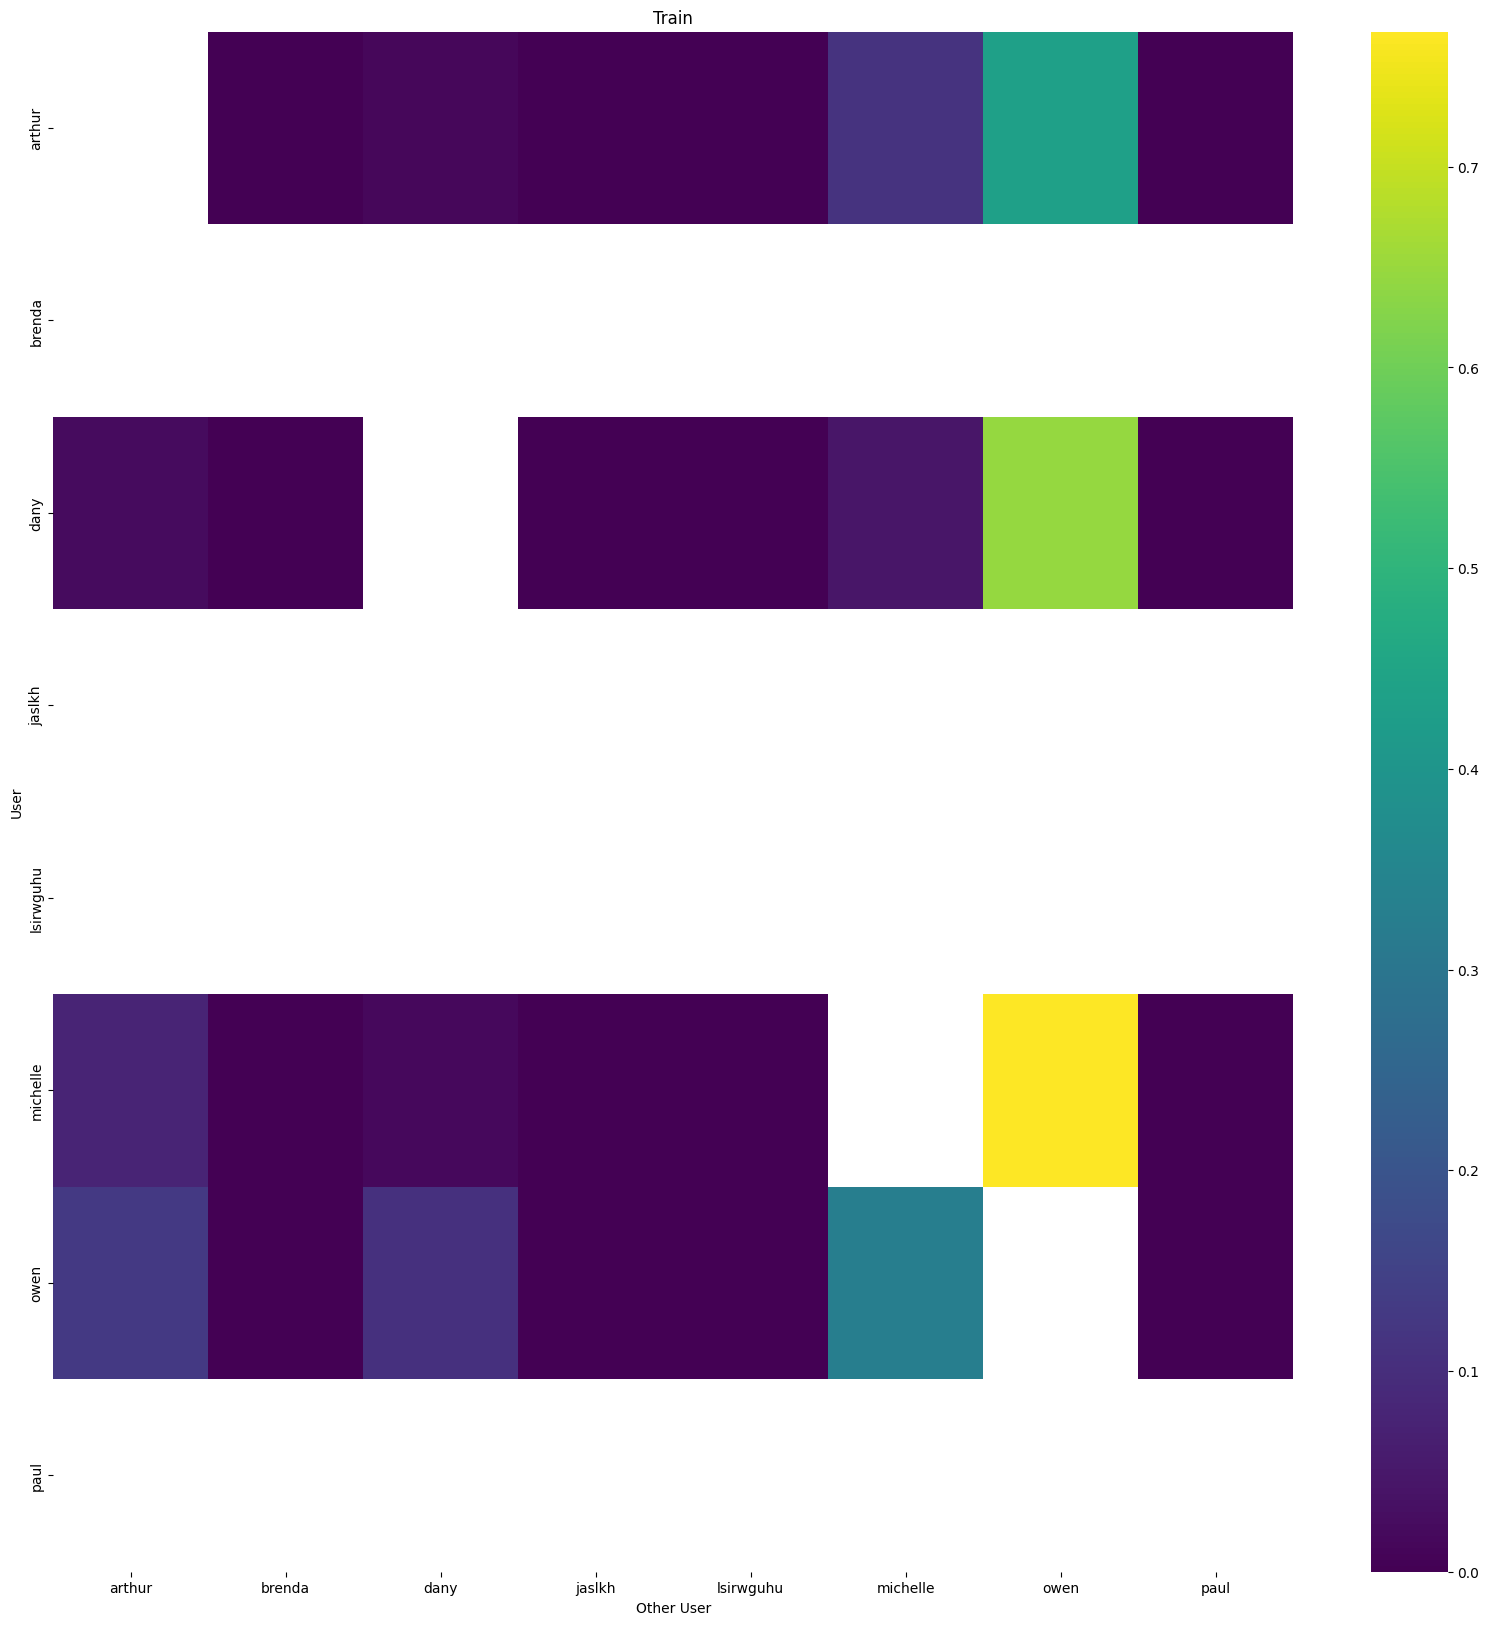

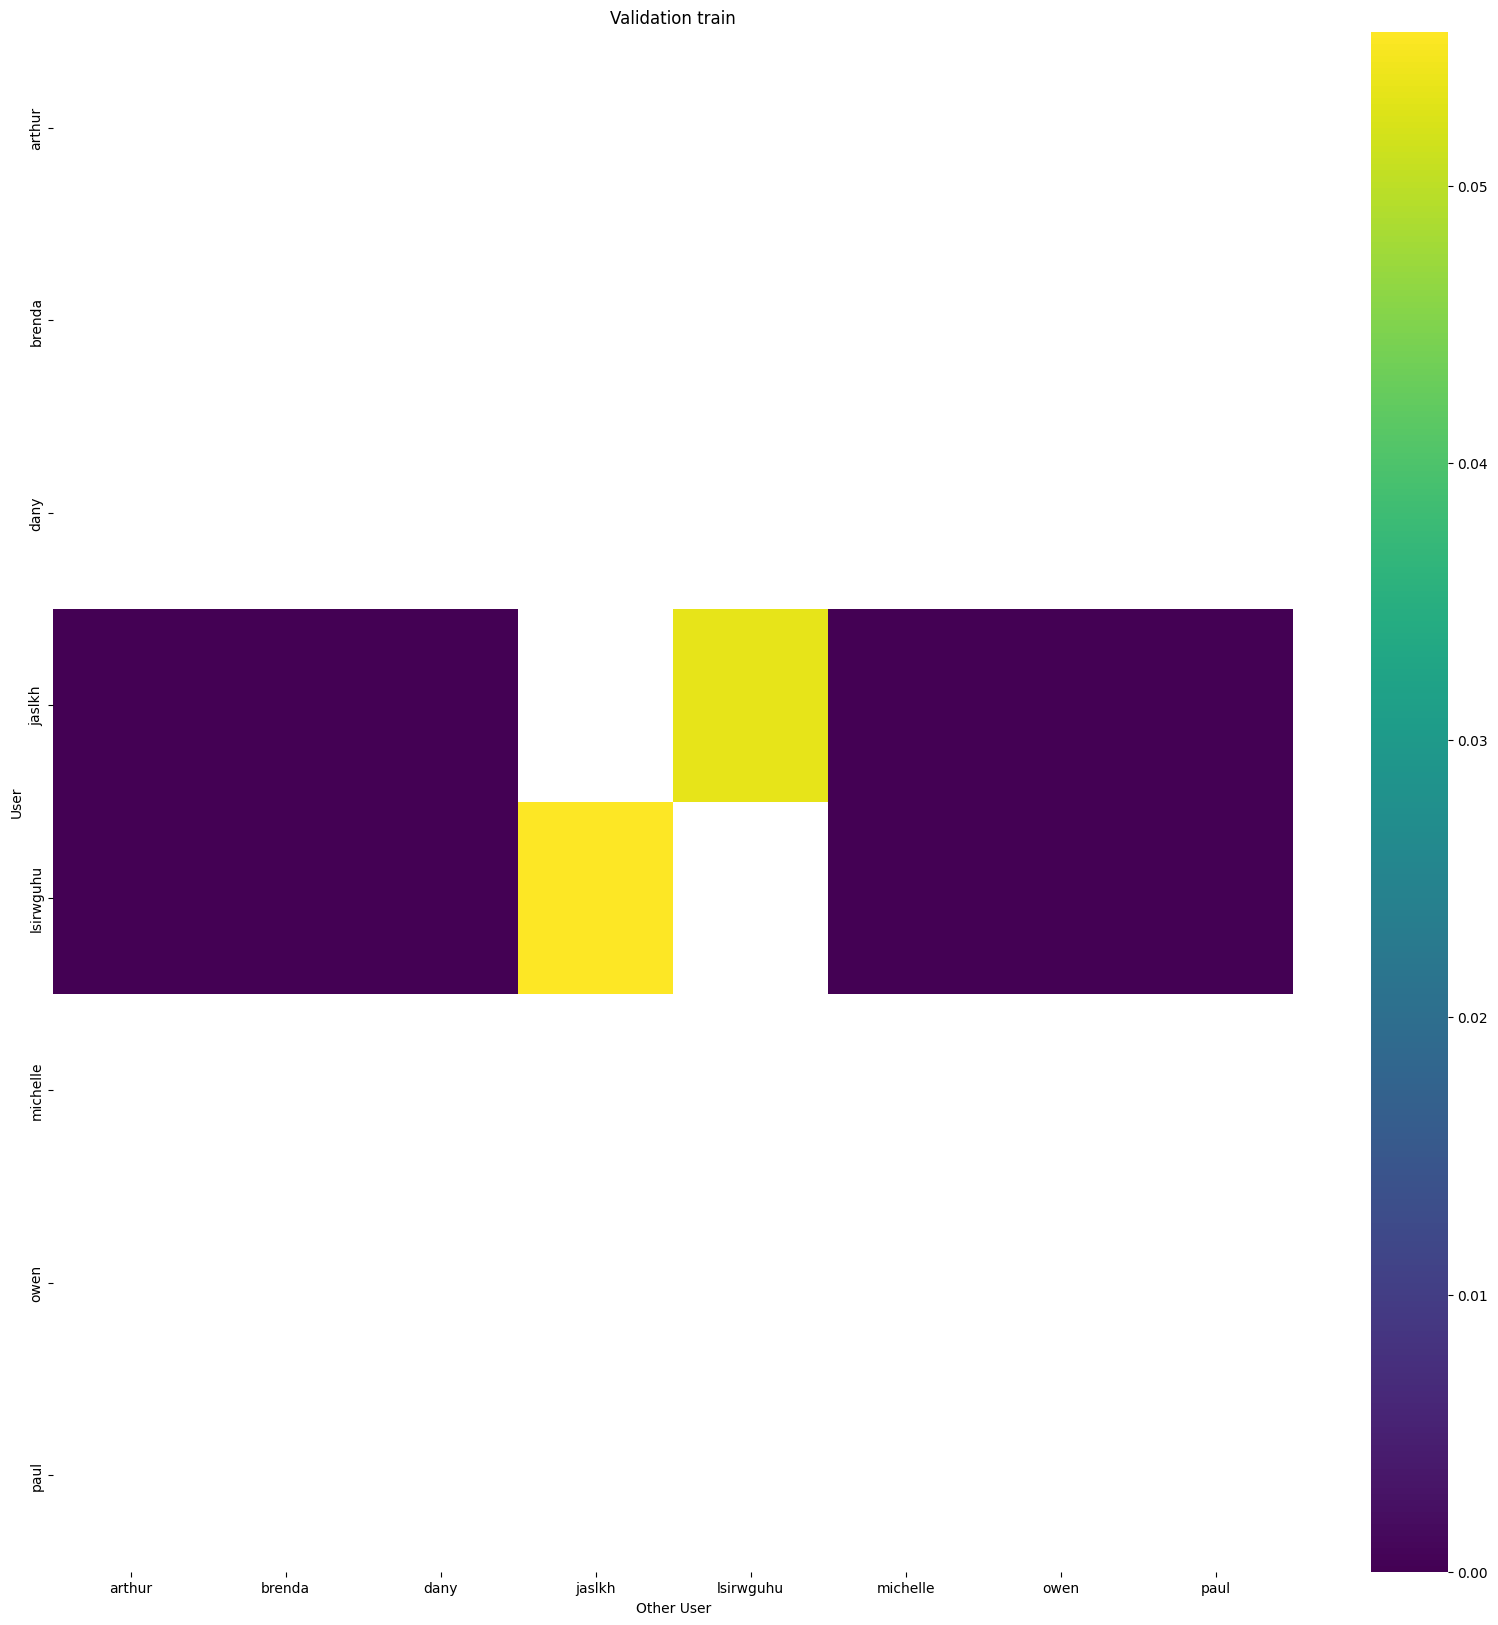

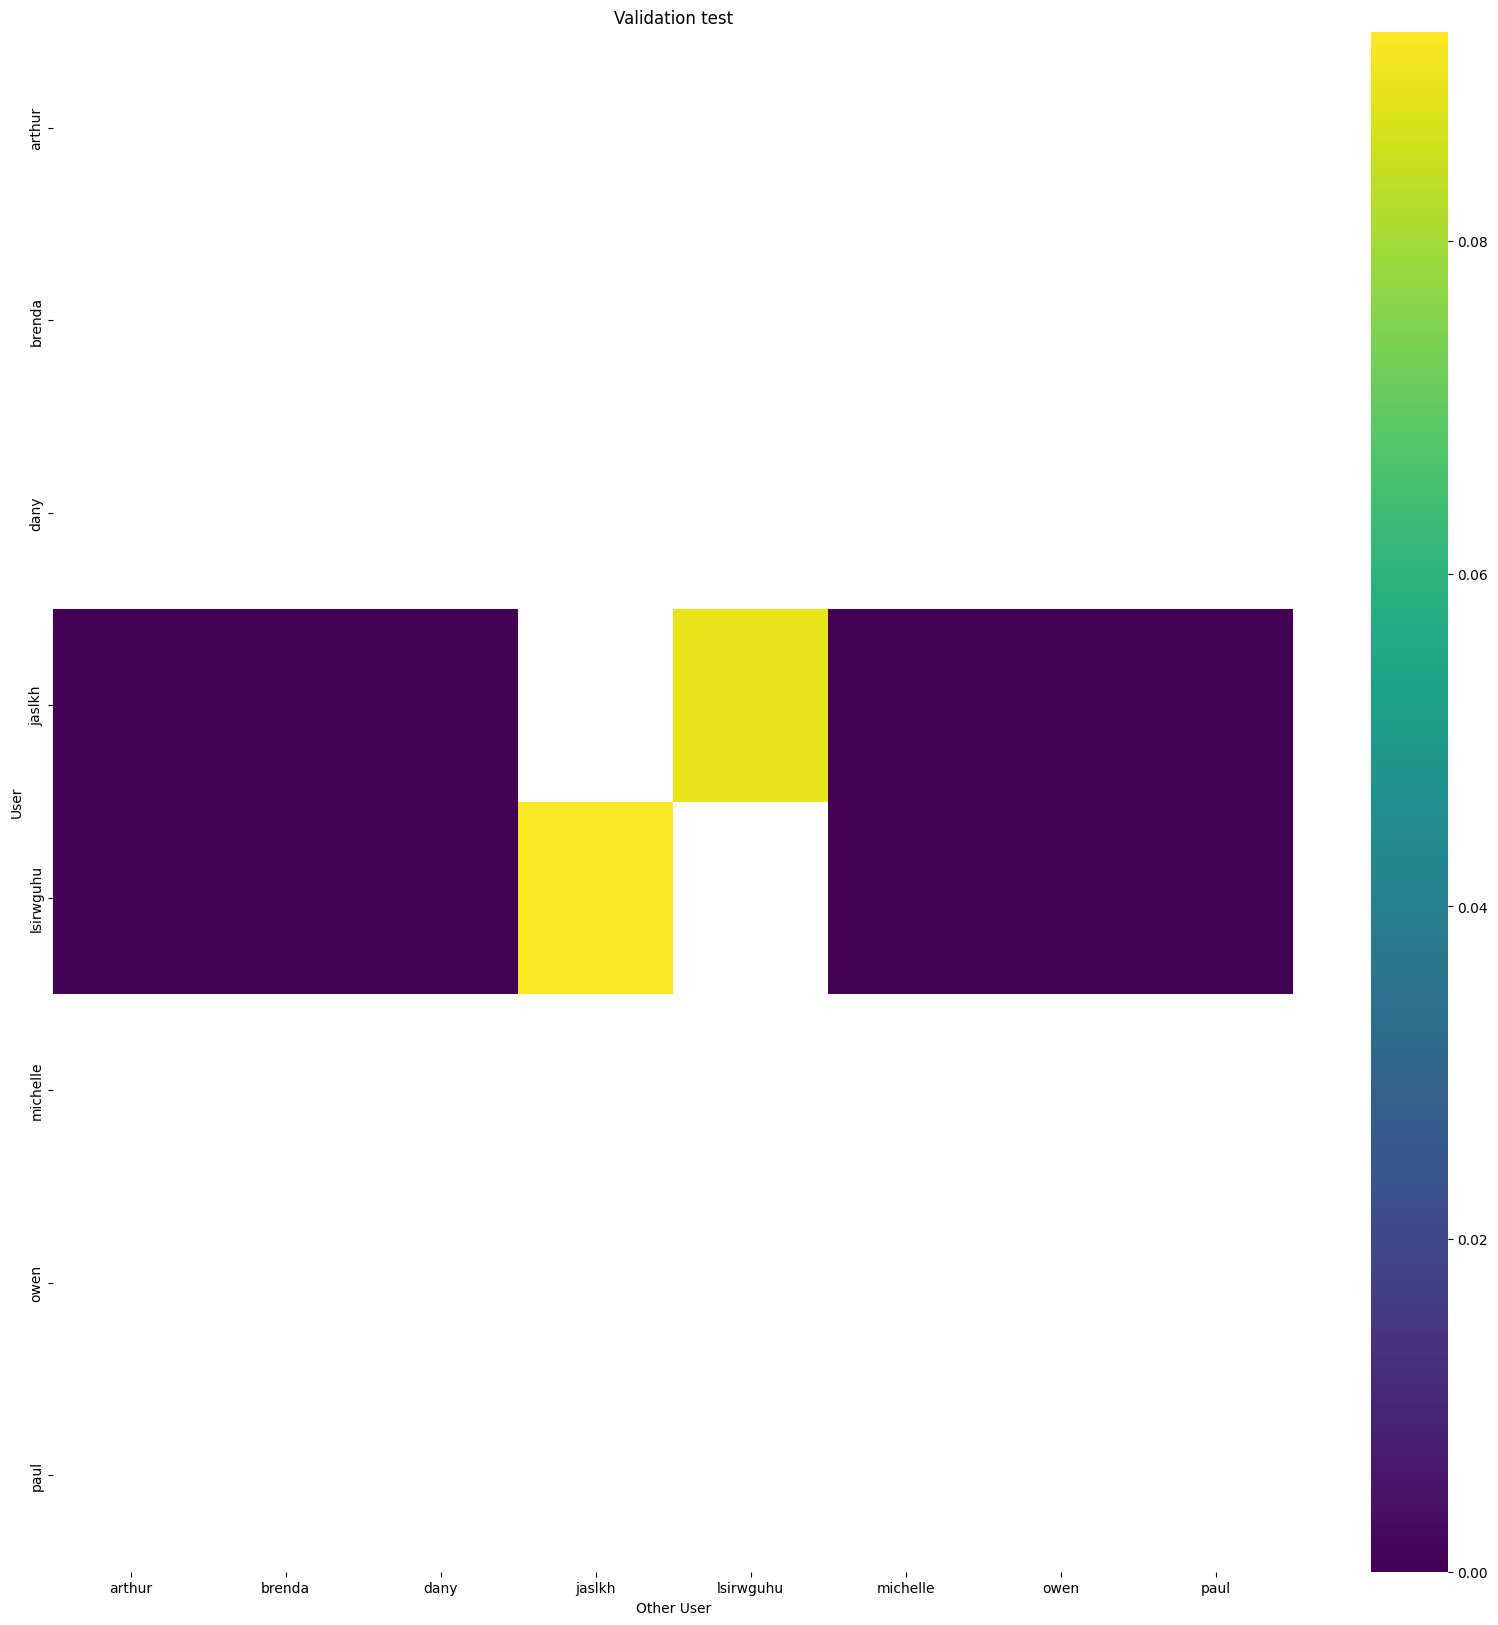

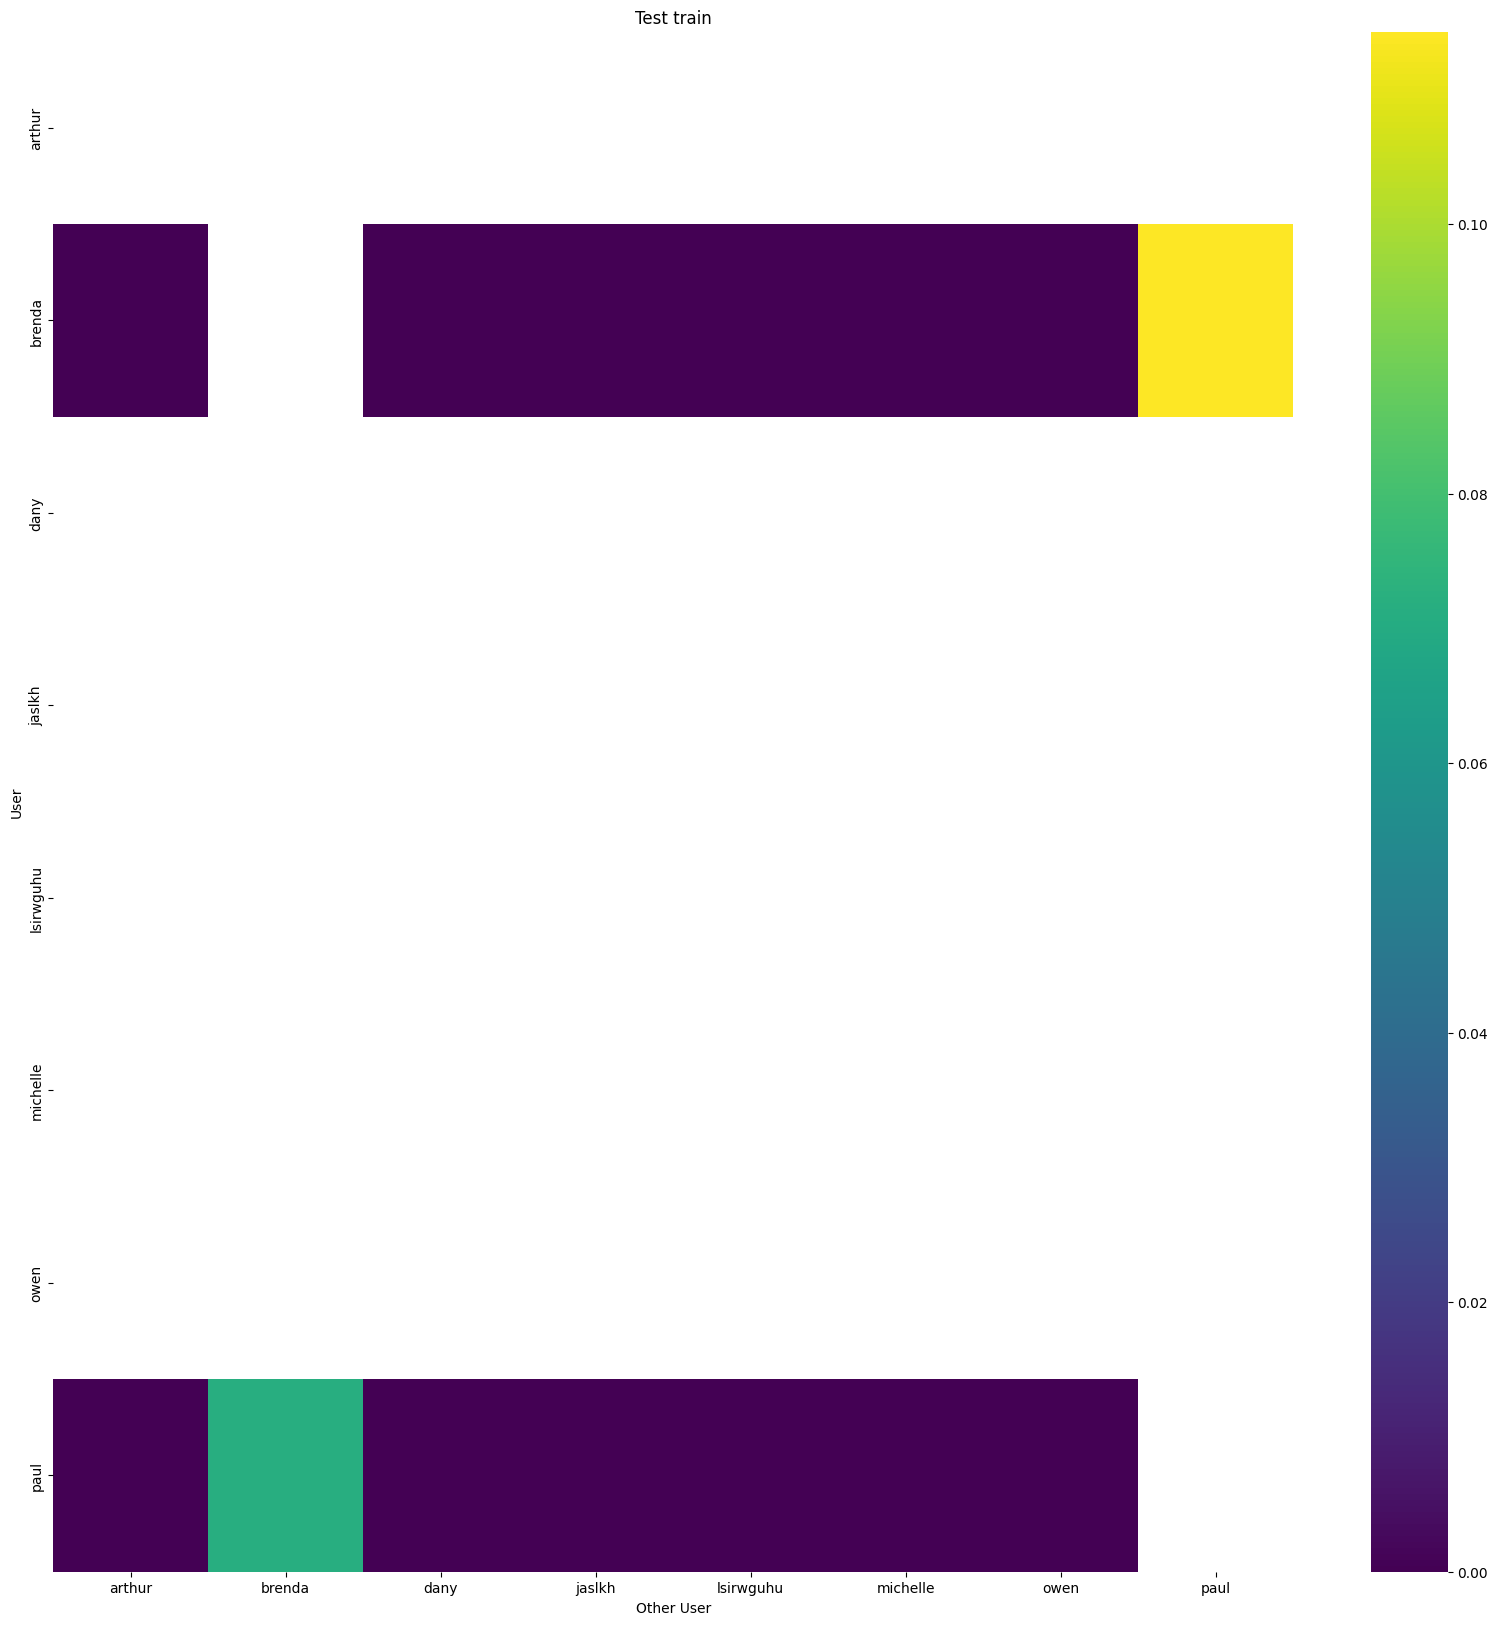

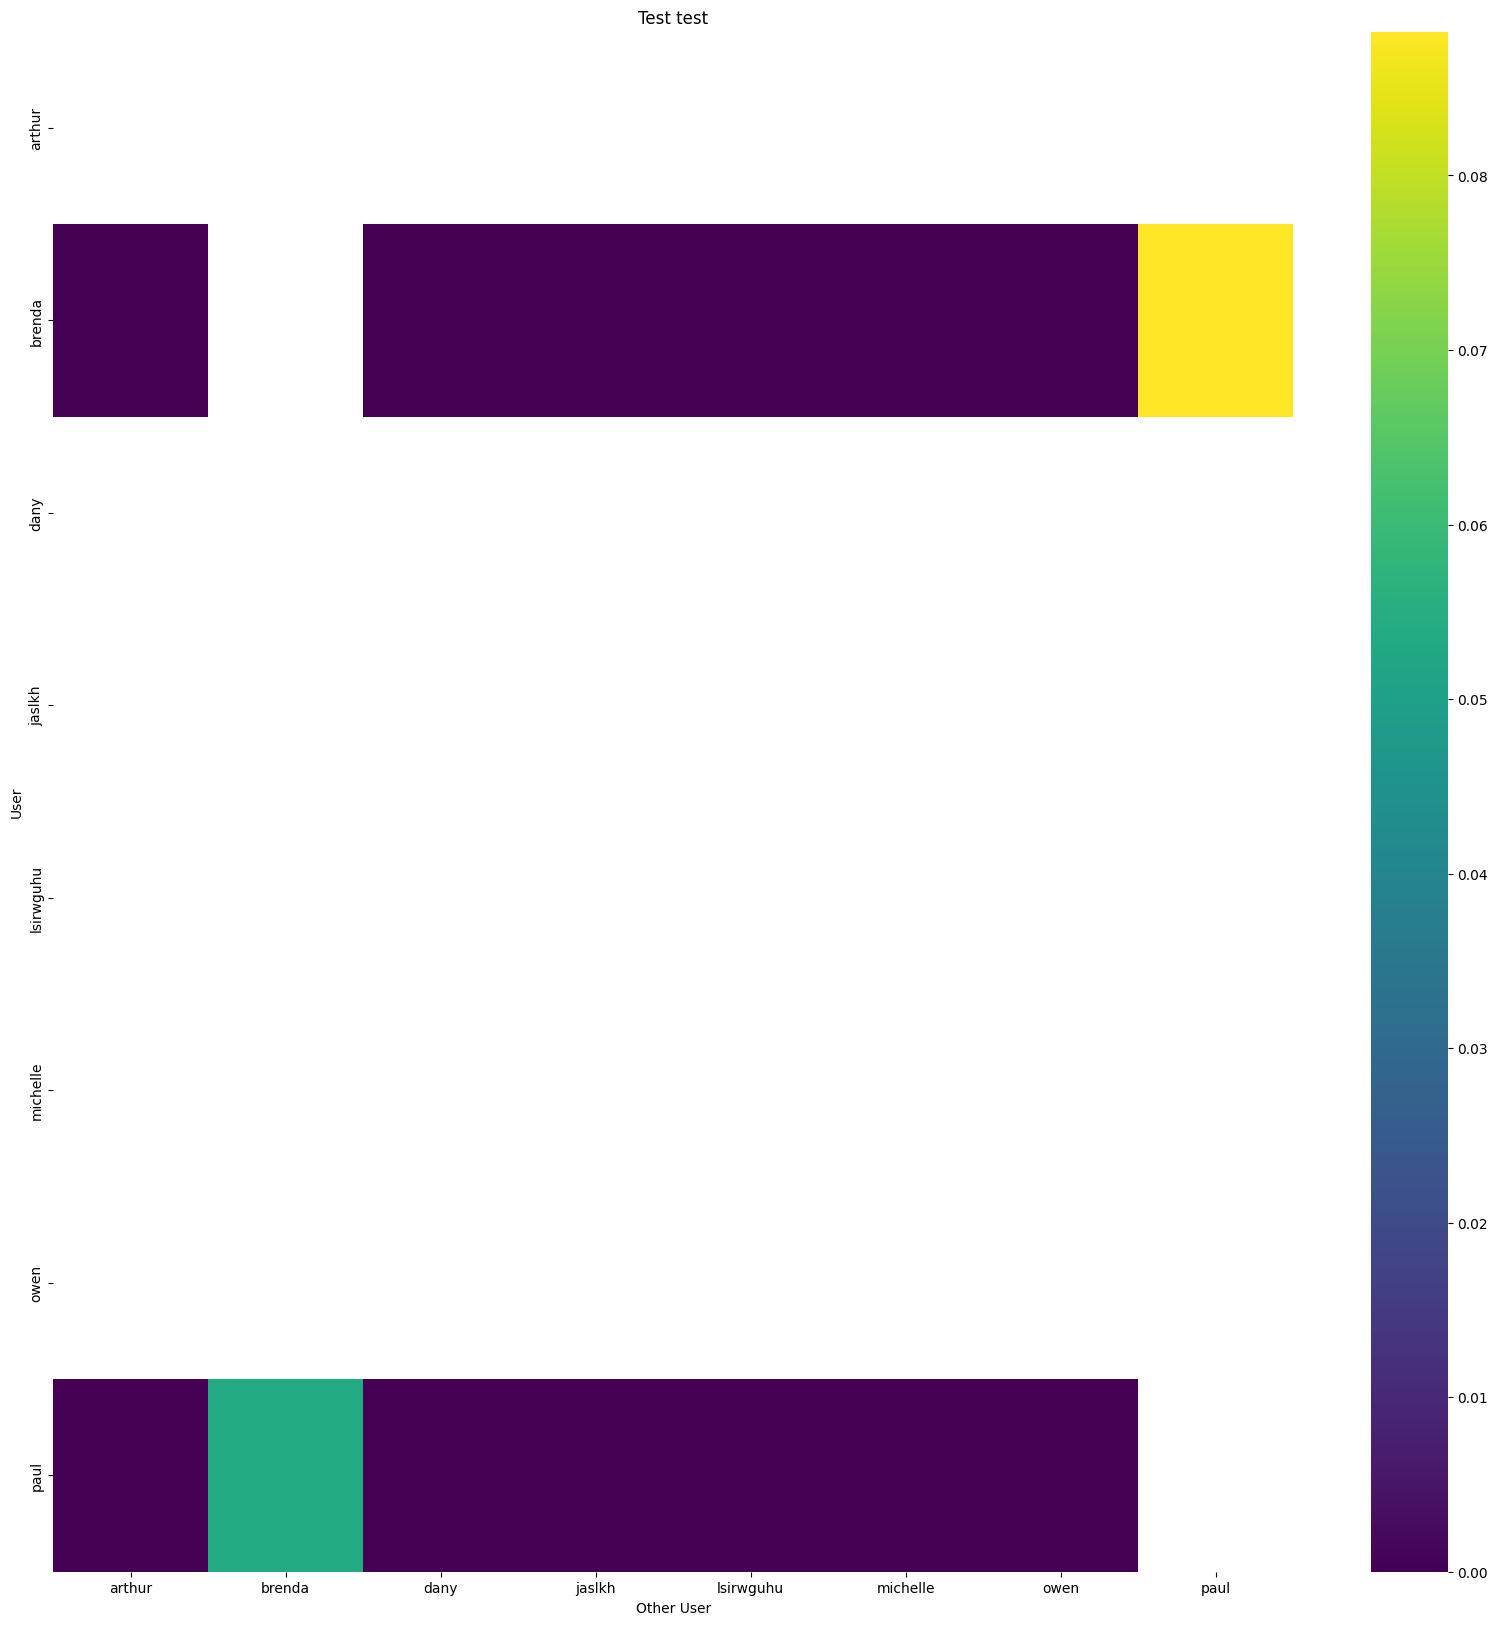

Alpha: 6.3247389793396
Min max affinity: 0.0 6.3247389793396
Min max affinity: 0.0 6.3247389793396
Min max affinity: 0.0 5.692265033721924
Min max affinity: 0.0 5.945254802703857
Min max affinity: 0.0 6.198244094848633
Min max affinity: 0.0 6.198244094848633
Max affinity: 6.3247389793396


In [11]:
train_df = df_matrix_mf_filtered[df_matrix_mf_filtered["username"].isin(train_df.index)]
# train_df["username"] = train_df["username"].cat.remove_unused_categories()
# train_df["id"] = train_df["id"].cat.remove_unused_categories()
print("Train data:")
display(train_df)

val_df_train, val_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=val_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
# val_df_train["username"] = val_df_train["username"].cat.remove_unused_categories()
# val_df_test["username"] = val_df_test["username"].cat.remove_unused_categories()
# val_df_train["id"] = val_df_train["id"].cat.remove_unused_categories()
# val_df_test["id"] = val_df_test["id"].cat.remove_unused_categories()
print("Validation train data:")
display(val_df_train)
print("Validation test data:")
display(val_df_test)

test_df_train, test_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=test_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
# test_df_train["username"] = test_df_train["username"].cat.remove_unused_categories()
# test_df_test["username"] = test_df_test["username"].cat.remove_unused_categories()
# test_df_train["id"] = test_df_train["id"].cat.remove_unused_categories()
# test_df_test["id"] = test_df_test["id"].cat.remove_unused_categories()
print("Test train data:")
display(test_df_train)
print("Test test data:")
display(test_df_test)

df_user_similarities = user_similarities.calculate_users_track_common_percentage(train_df, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation test")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test test")

(
    whole_matrix_dataset,
    train_matrix_dataset,
    validation_train_matrix_dataset,
    validation_test_matrix_dataset,
    test_train_matrix_dataset,
    test_test_matrix_dataset,
) = (
    MatrixDataset(
        df=df_matrix_mf_filtered,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=train_df,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
)

a = whole_matrix_dataset.compute_alpha()
whole_matrix_dataset.set_alpha(a)
# min_scale, max_scale = whole_matrix_dataset.min_max_scale(bounds=(0.0, 1.0))

for dataset in [train_matrix_dataset, validation_train_matrix_dataset, validation_test_matrix_dataset, test_train_matrix_dataset, test_test_matrix_dataset]:
    dataset.set_alpha(a)
    # dataset.min_max_scale(bounds=(0.0, 1.0), optimums=(min_scale, max_scale))

print(f"Alpha: {a}")
print(f"Min max affinity: {whole_matrix_dataset.R.min().item()} {whole_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {train_matrix_dataset.R.min().item()} {train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {validation_train_matrix_dataset.R.min().item()} {validation_train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {validation_test_matrix_dataset.R.min().item()} {validation_test_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {test_train_matrix_dataset.R.min().item()} {test_train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {test_test_matrix_dataset.R.min().item()} {test_test_matrix_dataset.R.max().item()}")

max_affinity = whole_matrix_dataset.R.max().item()
print(f"Max affinity: {max_affinity}")

In [12]:
print("Whole dataset shape:", whole_matrix_dataset.R.shape)
print("Train dataset shape:", train_matrix_dataset.R.shape)
print("Validation train dataset shape:", validation_train_matrix_dataset.R.shape)
print("Validation test dataset shape:", validation_test_matrix_dataset.R.shape)
print("Test train dataset shape:", test_train_matrix_dataset.R.shape)
print("Test test dataset shape:", test_test_matrix_dataset.R.shape)

Whole dataset shape: torch.Size([8, 428])
Train dataset shape: torch.Size([8, 428])
Validation train dataset shape: torch.Size([8, 428])
Validation test dataset shape: torch.Size([8, 428])
Test train dataset shape: torch.Size([8, 428])
Test test dataset shape: torch.Size([8, 428])


In [13]:
whole_matrix_dataset.R

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 1.8974],
        ...,
        [3.1624, 3.1624, 0.0000,  ..., 0.0000, 3.1624, 0.0000],
        [3.1624, 0.0000, 2.7829,  ..., 0.0000, 3.1624, 1.8974],
        [0.0000, 0.0000, 3.1624,  ..., 5.8188, 0.0000, 0.0000]],
       device='mps:0')

In [14]:
train_dataset = TensorDataset(train_matrix_dataset.R)
validation_dataset = TensorDataset(validation_train_matrix_dataset.R, validation_test_matrix_dataset.R)
test_dataset = TensorDataset(test_train_matrix_dataset.R, test_test_matrix_dataset.R)

# Define and train the MultiVAE model

In [15]:
p_dims = [200, 600, whole_matrix_dataset.R.shape[1]]
model = MultiVAE(p_dims=p_dims).to(device=device, dtype=dtype)
model

MultiVAE(
  (q_layers): ModuleList(
    (0): Linear(in_features=428, out_features=600, bias=True)
    (1): Linear(in_features=600, out_features=400, bias=True)
  )
  (p_layers): ModuleList(
    (0): Linear(in_features=200, out_features=600, bias=True)
    (1): Linear(in_features=600, out_features=428, bias=True)
  )
  (drop): Dropout(p=0.5, inplace=False)
)

In [16]:
batch_size = 32
anneal_cap = 0.2
total_anneal_steps = 200000

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
(
    best_model,
    loss_history,
    validation_loss_history,
    ndcg_history,
    r20_history,
    r50_history,
    mpr_history,
) = model.train_model(
    optimizer,
    train_loader,
    num_epochs=30,
    anneal_cap=anneal_cap,
    total_anneal_steps=total_anneal_steps,
    device=device,
    dtype=dtype,
    validation_dataloader=validation_loader,
    log_interval=1,
)

Epoch: 0 	 Loss: 1189.815674 	 Val Loss: 207.891861 	 NDCG_100: 0.040761 	 Recall_20: 0.100000 	 Recall_50: 0.110000 	 MPR: 0.545513
Epoch: 1 	 Loss: 1177.383057 	 Val Loss: 207.976868 	 NDCG_100: 0.036114 	 Recall_20: 0.100000 	 Recall_50: 0.110000 	 MPR: 0.552208
Epoch: 2 	 Loss: 1180.021973 	 Val Loss: 208.088882 	 NDCG_100: 0.035293 	 Recall_20: 0.150000 	 Recall_50: 0.120000 	 MPR: 0.562926
Epoch: 3 	 Loss: 1182.418701 	 Val Loss: 208.222748 	 NDCG_100: 0.034976 	 Recall_20: 0.150000 	 Recall_50: 0.130000 	 MPR: 0.575515
Epoch: 4 	 Loss: 1174.691284 	 Val Loss: 208.375137 	 NDCG_100: 0.034130 	 Recall_20: 0.175000 	 Recall_50: 0.110000 	 MPR: 0.588893
Epoch: 5 	 Loss: 1175.473389 	 Val Loss: 208.558807 	 NDCG_100: 0.034831 	 Recall_20: 0.175000 	 Recall_50: 0.120000 	 MPR: 0.599133
Epoch: 6 	 Loss: 1174.660889 	 Val Loss: 208.787811 	 NDCG_100: 0.034067 	 Recall_20: 0.125000 	 Recall_50: 0.110000 	 MPR: 0.607556
Epoch: 7 	 Loss: 1165.549561 	 Val Loss: 209.080948 	 NDCG_100: 0.031

In [17]:
losses_df = pd.DataFrame([loss_history, validation_loss_history, ndcg_history, r20_history, r50_history, mpr_history]).T
losses_df.columns = ["loss", "validation_loss", "ndgk", "r20", "r50", "mpr"]

px.line(losses_df, x=losses_df.index, y=["loss", "validation_loss"], title="Loss").show()
px.line(losses_df, x=losses_df.index, y=["ndgk", "r20", "r50", "mpr"], title="Metrics").show()

In [18]:
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
total_loss, ndcg, recall_20, recall_50, mpr = best_model.evaluate_model(
    test_loader,
    anneal_cap=anneal_cap,
    total_anneal_steps=total_anneal_steps,
    device=device,
    dtype=dtype,
)
print(f"Total loss: {total_loss}")
print(f"NDCG_100: {ndcg}")
print(f"Recall_20: {recall_20}")
print(f"Recall_50: {recall_50}")
print(f"MPR: {mpr}")

Total loss: 166.49456024169922
NDCG_100: 0.01568494364619255
Recall_20: 0.02500000037252903
Recall_50: 0.04470588266849518
MPR: 0.6185595393180847


In [19]:
# retrieve users latent representations (mean and variance)
user_names = df_matrix_mf["username"].sort_values().unique().tolist()
user_names

['arthur', 'brenda', 'dany', 'jaslkh', 'lsirwguhu', 'michelle', 'owen', 'paul']

In [20]:
z, mu, std, logvar = best_model.get_latent_representations(whole_matrix_dataset.R)

print(z.shape)
print(mu.shape)
print(std.shape)
print(logvar.shape)

torch.Size([8, 200])
torch.Size([8, 200])
torch.Size([8, 200])
torch.Size([8, 200])


In [21]:
# Define the number of points for grid, the width of the gaussian curves and color map
# dim1 = range(0, p_dims[0])
# dim2 = range(0, p_dims[0])
dim1 = range(10, 15)
dim2 = range(10, 15)

# for i in dim1:
#     for j in dim2:
#         if i >= j:
#             continue
#         # # Plot 2D latent space using and add annotations with usernames
#         # fig = px.scatter(x=z[:, i], y=z[:, j], hover_name=usersnames, color=usersnames)
#         # fig.update_traces(marker=dict(size=10))
#         # fig.update_layout(title="2D Latent Space")
#         # # Show the usernames next to the points
#         # for i_username, username in enumerate(usersnames):
#         #     fig.add_annotation(
#         #         x=z[i_username, i], y=z[i_username, j], text=username, showarrow=False, xshift=-20, yshift=15
#         #     )
#         # fig.show()
        
#         # Using sns
#         fig, ax = plt.subplots(figsize=(10, 5))
#         sns.scatterplot(x=z[:, i], y=z[:, j], hue=usersnames, ax=ax)
#         for i_username, username in enumerate(usersnames):
#             ax.text(z[i_username, i], z[i_username, j] + 0.3, username, fontsize=8)
#         ax.set_title(f"2D Latent Space ({i}, {j})")
#         ax.set_xlabel(f"z{i}")
#         ax.set_ylabel(f"z{j}")
#         plt.show()

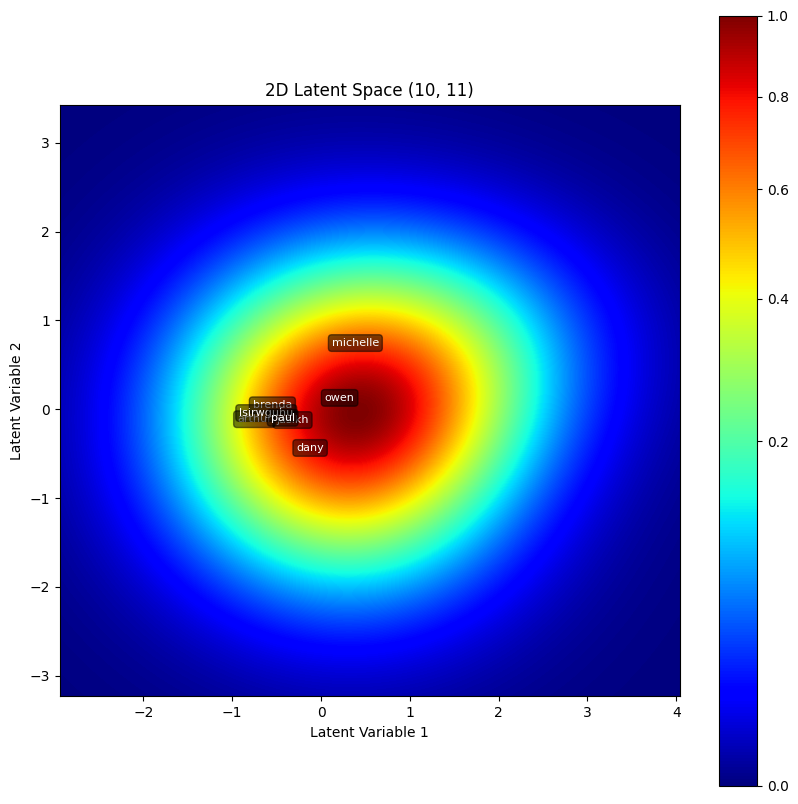

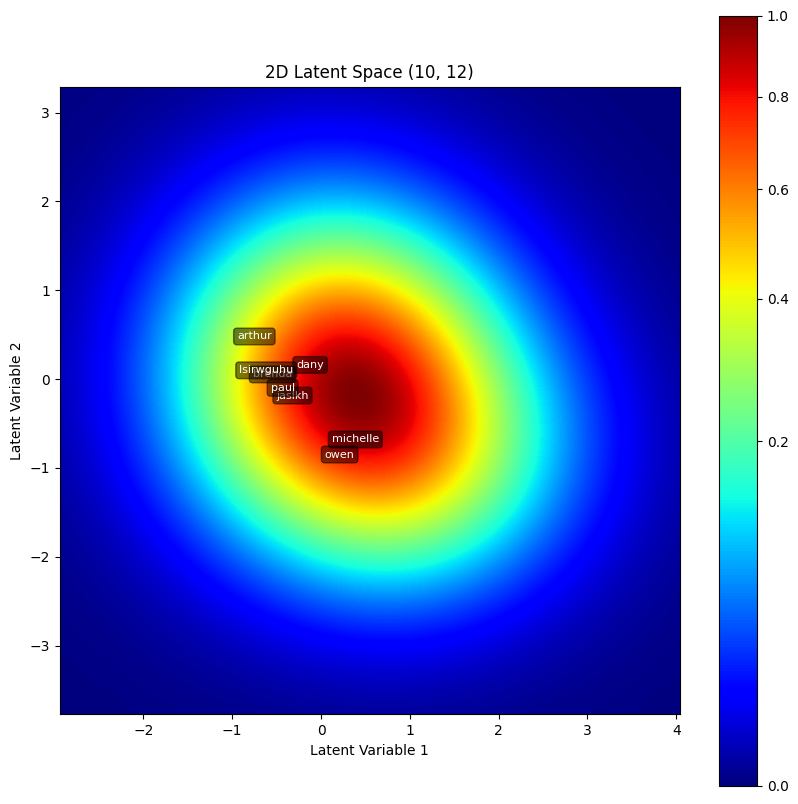

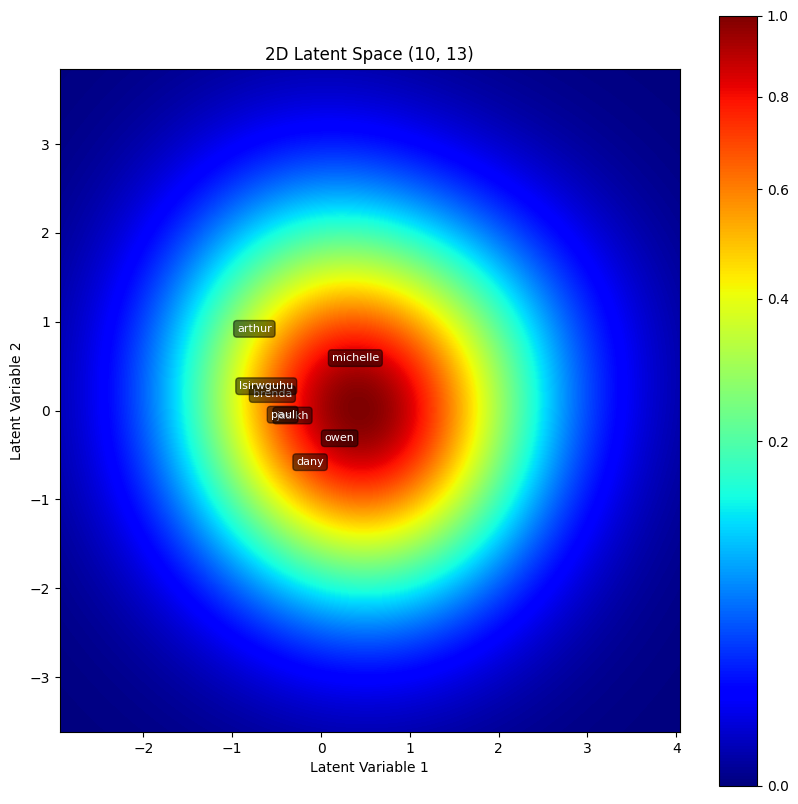

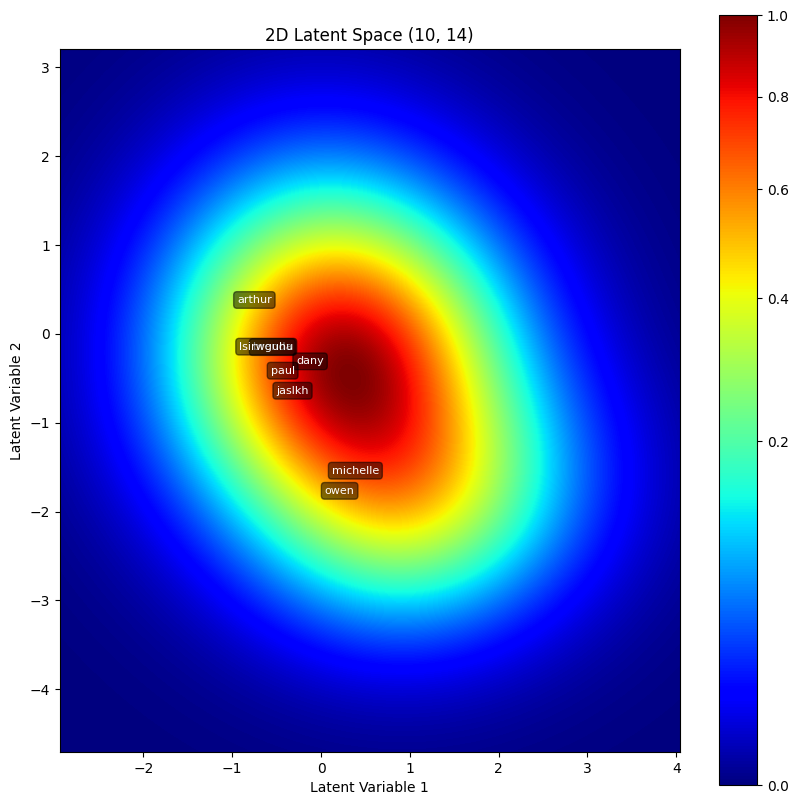

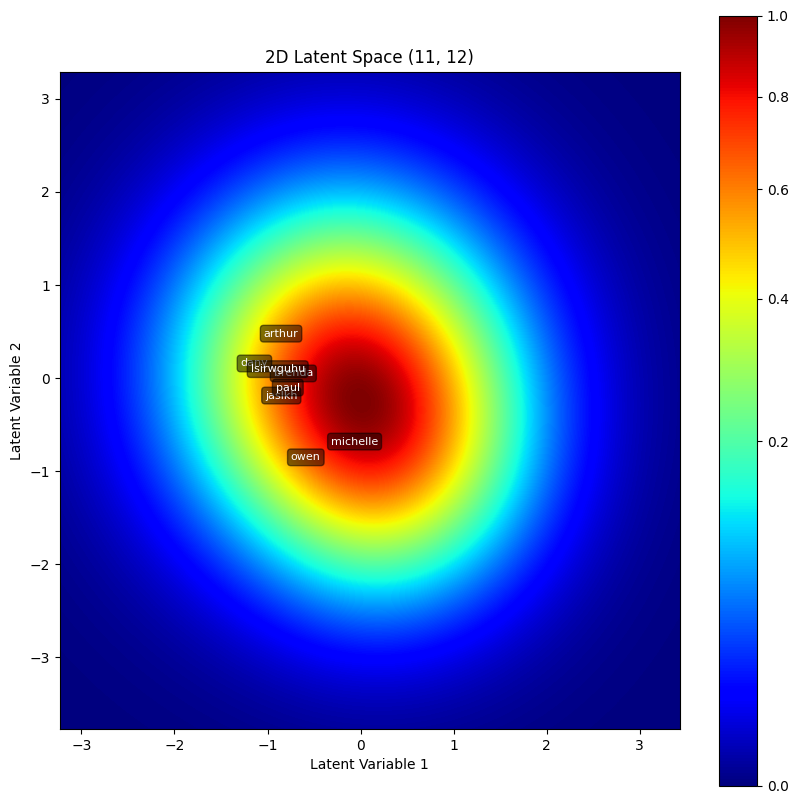

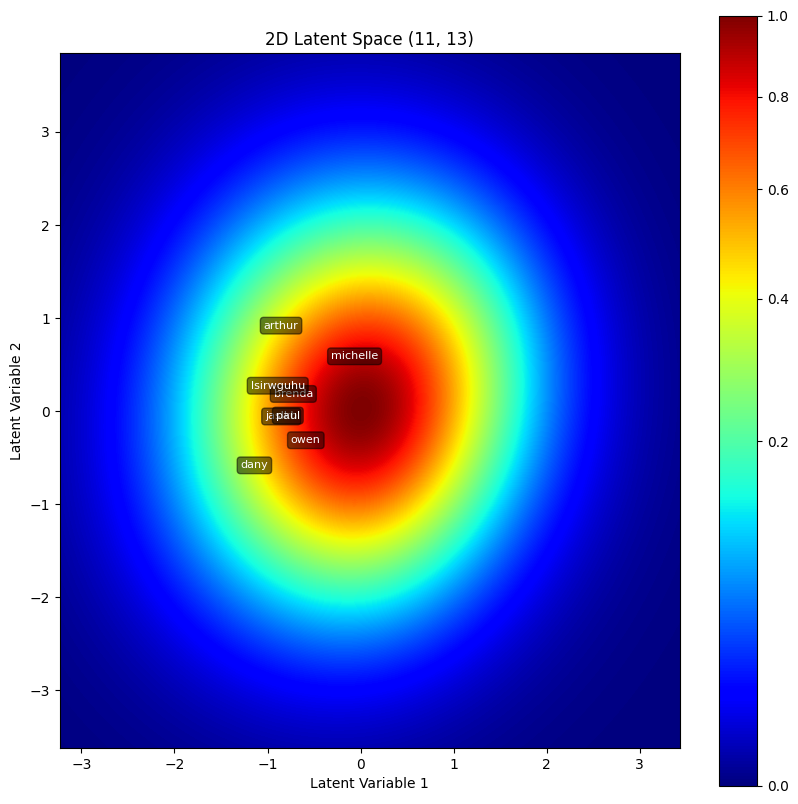

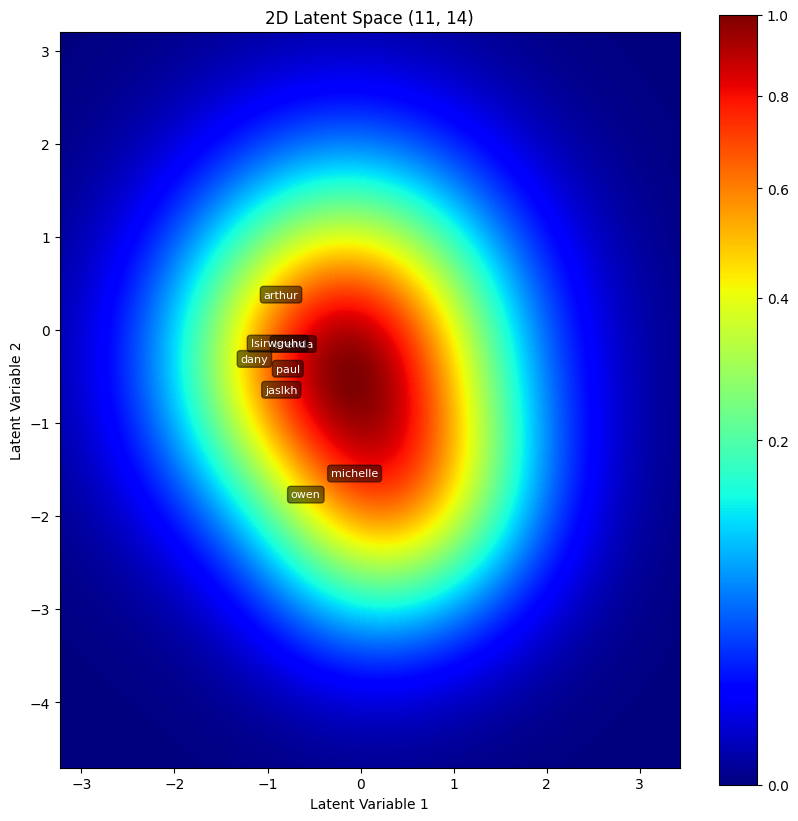

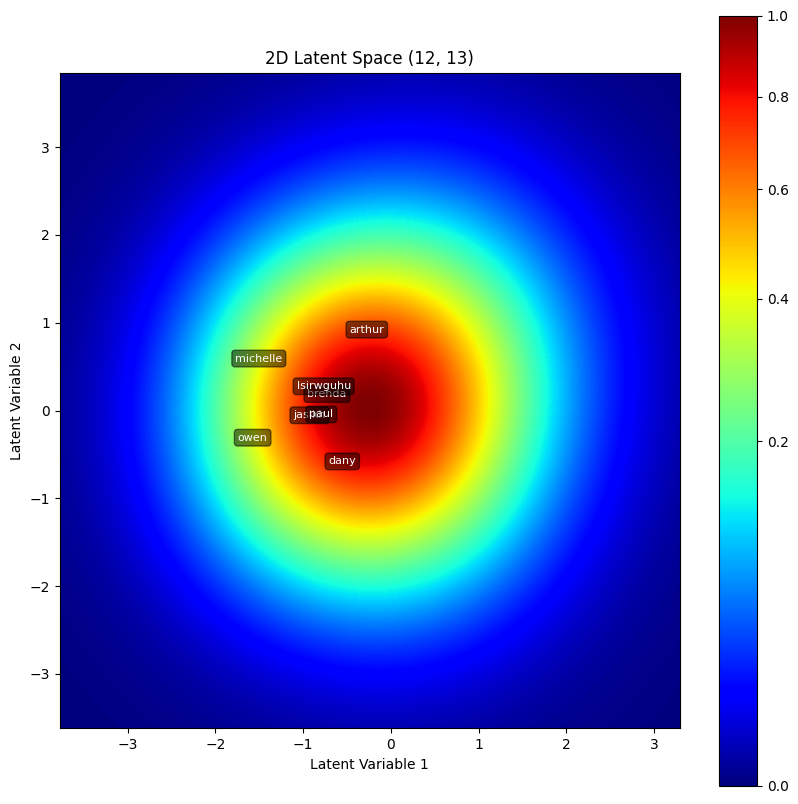

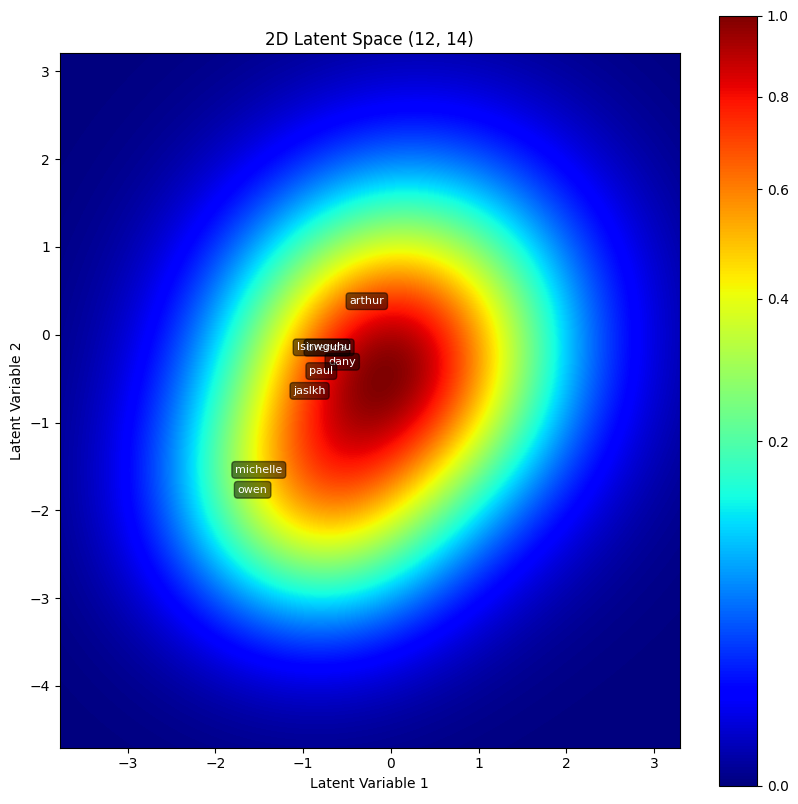

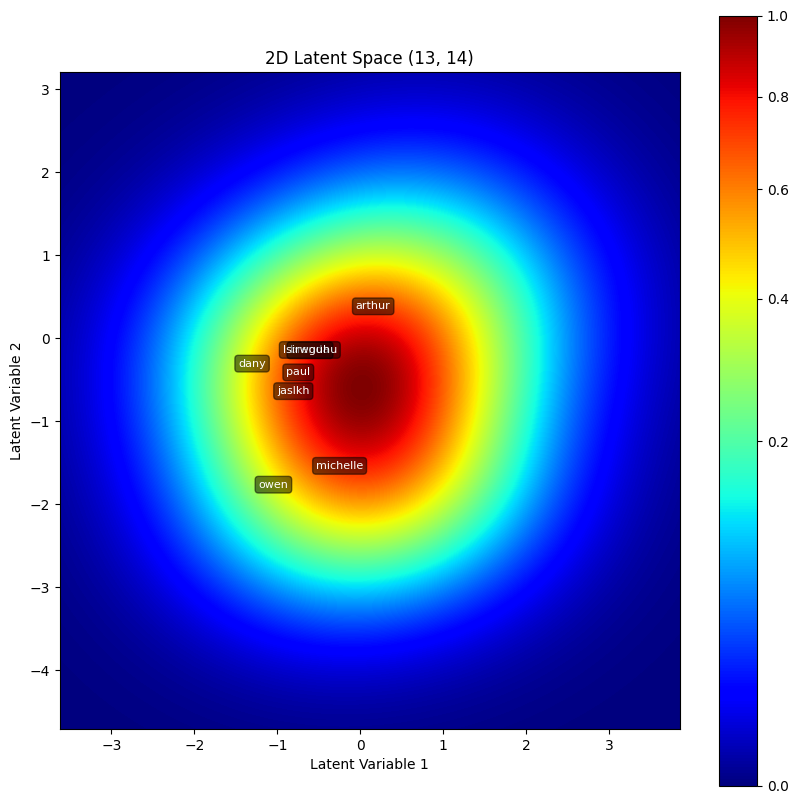

In [22]:
for i in dim1:
    for j in dim2:
        if i >= j:
            continue
        plotting.plot_multivariate_gaussian_image_with_labels(
            mu.cpu().numpy()[:, [i, j]],
            std.cpu().numpy()[:, [i, j]],
            color_map="jet",
            # dpi=300,
            labels=user_names,
            title=f"2D Latent Space ({i}, {j})",
        )

In [23]:
username = "owen"
user_id = whole_matrix_dataset.usernames_to_ids([username])[0]
username = whole_matrix_dataset.ids_to_usernames([user_id])[0]
print(f"User id: {user_id}, {username}")
user_seen = whole_matrix_dataset.get_interactions_ids(user_id)
user_seen.cpu().numpy().shape

User id: 6, owen


(274,)

In [24]:
user_seen.cpu().numpy()

array([  0,   2,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  15,
        16,  18,  22,  24,  26,  28,  29,  32,  33,  34,  35,  38,  39,
        40,  41,  42,  44,  48,  51,  52,  53,  54,  56,  57,  58,  60,
        63,  65,  67,  69,  70,  71,  72,  74,  75,  77,  78,  79,  80,
        81,  82,  83,  85,  87,  88,  90,  91,  92,  93,  95,  96,  97,
        98,  99, 101, 102, 104, 108, 109, 111, 112, 114, 115, 116, 117,
       118, 124, 125, 126, 127, 132, 133, 135, 136, 139, 140, 143, 144,
       147, 150, 151, 152, 158, 159, 163, 164, 165, 167, 170, 171, 174,
       175, 176, 180, 182, 184, 186, 187, 188, 189, 191, 192, 196, 197,
       198, 199, 200, 202, 204, 205, 207, 208, 210, 212, 214, 215, 216,
       217, 218, 220, 222, 224, 225, 226, 227, 228, 229, 230, 234, 235,
       237, 239, 240, 241, 243, 244, 245, 247, 248, 249, 251, 254, 255,
       256, 258, 259, 260, 261, 265, 266, 267, 268, 269, 272, 273, 276,
       277, 278, 280, 281, 282, 284, 285, 289, 290, 291, 292, 29

In [25]:
similar_users_ids = best_model.sort_similar_users(user_id=user_id, latent_representations=z)
most_similar_users = whole_matrix_dataset.ids_to_usernames(similar_users_ids.cpu().numpy())[1:]
most_similar_users

['jaslkh', 'paul', 'michelle', 'brenda', 'lsirwguhu', 'dany', 'arthur']

In [29]:
items_ids, predicted_scores = best_model.recommend(matrix=whole_matrix_dataset.R)
recommendation_df: pd.DataFrame = whole_matrix_dataset.df.copy()
recommendation_df["item_id"] = recommendation_df["id"].cat.codes.astype("int")
recommendation_df.set_index("item_id", inplace=True)

# Get df in the same order as the ids
recommendation_df = recommendation_df.loc[items_ids.cpu().numpy()[user_id]]
recommendation_df["predicted_scores"] = pd.Series(predicted_scores.cpu().numpy()[user_id], index=items_ids.cpu().numpy()[user_id])

recommendation_df = recommendation_df[recommendation_df["username"] != username]
recommendation_df = recommendation_df.drop_duplicates(subset=["username", "id"])
recommendation_df["seen"] = recommendation_df.index.isin(user_seen.cpu().numpy())
# recommendation_df = recommendation_df[recommendation_df["seen"] == False]
recommendation_df = recommendation_df.drop_duplicates(subset=["id"])
recommendation_df = recommendation_df.sort_values(by="predicted_scores", ascending=False)

columns = spoti.PRETTY_PRINT_FEATURES
columns = list(recommendation_df.columns)
recommendation_df[["id", "predicted_scores", "seen"] + columns].head(100)[spoti.PRETTY_PRINT_FEATURES]

,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
item_id,,,,,,,,,,,,,,,,,
272,michelle,Mom Jeans.,Scott Pilgrim vs. My GPA,2016,58,0.296,0.494,0.0370,0.07150,0.050700,0.1080,0.175,163.669,-10.490,239597,2016,58
296,arthur,Foo Fighters,Everlong,1997,87,0.413,0.881,0.0367,0.00006,0.000308,0.0805,0.364,158.066,-5.541,250546,1997,87
243,michelle,Harry Styles,As It Was,2022,69,0.520,0.731,0.0557,0.34200,0.001010,0.3110,0.662,173.930,-5.338,167303,2022,69
351,arthur,The Killers,Somebody Told Me,2004,82,0.497,0.970,0.0836,0.00009,0.000674,0.1010,0.689,138.081,-4.851,197200,2004,82
359,jaslkh,Iliona,Garçon manqué,2022,45,0.822,0.399,0.0381,0.69300,0.101000,0.1030,0.399,119.981,-9.382,211386,2022,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,michelle,WILLOW,t r a n s p a r e n t s o u l feat. Travis Barker,2021,65,0.390,0.830,0.0563,0.00210,0.000000,0.1560,0.191,90.021,-5.201,168030,2021,65
368,arthur,Gotye,Somebody That I Used To Know,2011,66,0.862,0.515,0.0368,0.54500,0.000153,0.0899,0.696,129.044,-6.897,244893,2011,66
72,michelle,Human Tetris,Long Flight,2018,49,0.587,0.706,0.0348,0.00007,0.756000,0.1280,0.529,95.008,-6.004,251368,2018,49
